In [1]:
# all imports
import carla #the sim library itself
import time #to set a delay after each photo
import cv2 # to work with images from cameras
import numpy as np #to change image representation
import math

In [2]:
client = carla.Client('localhost', 2000)

world = client.get_world()
spawn_points = world.get_map().get_spawn_points()

vehicle_bp = world.get_blueprint_library().filter('*firetruck*')
start_point = spawn_points[0]
vehicle = world.try_spawn_actor(vehicle_bp[0], start_point)

In [5]:
# send vehicle off
vehicle.set_autopilot(True)

In [7]:
for actor in world.get_actors().filter('*vehicle*'):
    actor.destroy()
for sensor in world.get_actors().filter('*sensor*'):
    sensor.destroy()

In [11]:
# initial spawn point is the same - just 0.6m higher off the ground
print(start_point)

Transform(Location(x=-64.644844, y=24.471010, z=0.600000), Rotation(pitch=0.000000, yaw=0.159198, roll=0.000000))


In [13]:
# get the car's position on the map
vehicle_pos = vehicle.get_transform()
print(vehicle_pos)

Transform(Location(x=0.000000, y=0.000000, z=0.000000), Rotation(pitch=0.000000, yaw=0.000000, roll=0.000000))


In [15]:
# now look at the map
town_map = world.get_map()

In [17]:
type(town_map)
roads = town_map.get_topology()

In [19]:
print(roads
     )

[(<carla.libcarla.Waypoint object at 0x0000015A7DE39BD0>, <carla.libcarla.Waypoint object at 0x0000015A7DE39B10>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39750>, <carla.libcarla.Waypoint object at 0x0000015A7DE39870>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39F30>, <carla.libcarla.Waypoint object at 0x0000015A7DE399F0>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39930>, <carla.libcarla.Waypoint object at 0x0000015A7DE39E70>), (<carla.libcarla.Waypoint object at 0x0000015A7DE394B0>, <carla.libcarla.Waypoint object at 0x0000015A7DE39E10>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39810>, <carla.libcarla.Waypoint object at 0x0000015A7DE39C90>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39CF0>, <carla.libcarla.Waypoint object at 0x0000015A7DE39570>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39D50>, <carla.libcarla.Waypoint object at 0x0000015A7DE39DB0>), (<carla.libcarla.Waypoint object at 0x0000015A7DE39390>, <carla.libcarla.Waypoint objec

In [21]:
# have a look at a waypoint - it is transform wrapped as a waypoint
print(roads[0][0])

Waypoint(Transform(Location(x=109.929878, y=-9.334196, z=0.000000), Rotation(pitch=0.000000, yaw=-89.609253, roll=0.000000)))


In [23]:
len (roads)

200

In [25]:
pip install networkx


  Using cached networkx-2.6.3-py3-none-any.whl (1.9 MB)


In [26]:
import sys
sys.path.append('C:\CARLA_0.9.14\WindowsNoEditor\PythonAPI\carla')
from agents.navigation.global_route_planner import GlobalRoutePlanner

In [27]:
# using the code to plan the route and then draw it in the simulator
# town10hd_map = world.get_map()

sampling_resolution = 2

grp = GlobalRoutePlanner(town_map, sampling_resolution)

point_a = carla.Location(x=-64.644844, y=24.471010, z=0.600000)
point_b = carla.Location(x=-114.478943, y=65.782814, z=-0.003669)

route = grp.trace_route(point_a, point_b)

for waypoint in route:
    world.debug.draw_string(
        waypoint[0].transform.location,
        '^',
        draw_shadow=False,
        color=carla.Color(r=0, g=0, b=255),
        life_time=120.0,
        persistent_lines=True)

In [28]:
# now we define 2 cars
truck_bp = world.get_blueprint_library().filter('*firetruck*')
mini_bp = world.get_blueprint_library().filter('*cooper_s*')

# starting first car in already defined start point
truck = world.try_spawn_actor(truck_bp[0], start_point)

In [29]:
# tweaking spectator position
spectator = world.get_spectator()

spawn_points = world.get_map().get_spawn_points()
start_point = spawn_points[0]

spectator_pos = carla.Transform(
    start_point.location + carla.Location(x=20, y=10, z=4),
    carla.Rotation(yaw=start_point.rotation.yaw - 155)
)

spectator.set_transform(spectator_pos)

In [35]:
# drop the Mini in the sky 

mini = world.try_spawn_actor(mini_bp[0], spawn_points[10])

mini_pos = carla.Transform(
    start_point.location + carla.Location(x=-4,z=10),
    carla.Rotation(yaw=start_point.rotation.yaw - 0)
)

mini.set_transform(mini_pos)

In [3]:
# defining environment/world and getting possible places to spawn a car
# starting a car
client = carla.Client('localhost', 2000)
world = client.get_world()
spawn_points = world.get_map().get_spawn_points()

# look for a blueprint of Mini car
vehicle_bp = world.get_blueprint_library().filter('*mini*')

start_point = spawn_points[0]
vehicle = world.try_spawn_actor(vehicle_bp[0], start_point)


# camera mount offset on the car - we can tweak these to have the car in view
CAMERA_POS_Z = 3
CAMERA_POS_X = -5

camera_bp = world.get_blueprint_library().find('sensor.camera.rgb')
camera_bp.set_attribute('image_size_x', '640')  # this ratio works in CARLA 0.9.14
camera_bp.set_attribute('image_size_y', '360')

camera_init_trans = carla.Transform(
    carla.Location(z=CAMERA_POS_Z, x=CAMERA_POS_X)
)

# this creates the camera in the sim
camera = world.spawn_actor(camera_bp, camera_init_trans, attach_to=vehicle)


def camera_callback(image, data_dict):
    data_dict['image'] = np.reshape(
        np.copy(image.raw_data),
        (image.height, image.width, 4)
    )


image_w = camera_bp.get_attribute('image_size_x').as_int()
image_h = camera_bp.get_attribute('image_size_y').as_int()

camera_data = {'image': np.zeros((image_h, image_w, 4))}

# this opens a live stream from the camera
camera.listen(lambda image: camera_callback(image, camera_data))


In [5]:
"""

First we need to create controls functions so we could
push the car along the route
"""

# defining speed constants
PREFERRED_SPEED = 20  # what it says
SPEED_THRESHOLD = 2   # defines when we get close to desired speed

# adding params to display text to image
font = cv2.FONT_HERSHEY_SIMPLEX

# org - defining lines to display telemetry values on the screen
org = (30, 30)  # this line will be used to show current speed
org2 = (30, 50) # this line will be used for future steering angle
org3 = (30, 70) # and another line for future telemetry outputs

fontScale = 0.5

# white color
color = (255, 255, 255)

# line thickness of 2 px
thickness = 1


def maintain_speed(s):
    """
    this is a very simple function to maintain desired speed
    s arg is actual current speed
    """

    if s >= PREFERRED_SPEED:
        return 0
    elif s < PREFERRED_SPEED - SPEED_THRESHOLD:
        return 0.8  # think of it as % of "full gas"
    else:
        return 0.4  # tweaking this if the car is way over or under preferred speed

In [7]:
# now little demo to drive straight
# close to a desired speed

# - press Q to exit, you need to run the bit above to start the car

cv2.namedWindow("RGB Camera", cv2.WINDOW_AUTOSIZE)
cv2.imshow("RGB Camera", camera_data['image'])

# main loop
quit = False

while True:
    # Carla Tick
    world.tick()

    if cv2.waitKey(1) == ord('q'):
        quit = True
        break

    image = camera_data['image']

    steering_angle = 0  # we do not have it yet

    # to get speed we need to use 'get velocity' function
    v = vehicle.get_velocity()

    # velocity is a vector in 3D
    # speed is like hypotenuse in a right triangle
    # convert from m/s to km/h → multiply by 3.6
    speed = round(3.6 * math.sqrt(v.x**2 + v.y**2 + v.z**2), 2)

    # add speed to camera window
    image = cv2.putText(
        image,
        'Speed: ' + str(int(speed)) + ' km/h',
        org,
        font,
        fontScale,
        color,
        thickness,
        cv2.LINE_AA
    )

    # estimate throttle
    estimated_throttle = maintain_speed(speed)

    # apply control
    vehicle.apply_control(
        carla.VehicleControl(
            throttle=estimated_throttle,
            steer=steering_angle
        )
    )

    cv2.imshow("RGB Camera", image)


# clean up
cv2.destroyAllWindows()
camera.stop()

for actor in world.get_actors().filter('*vehicle*'):
    actor.destroy()

for sensor in world.get_actors().filter('*sensor*'):
    sensor.destroy()

In [5]:
import carla
import numpy as np
import cv2
import time

# Global frame storage
latest_frame = None

# Process image from camera
def process_image(image):
    global latest_frame
    img = np.frombuffer(image.raw_data, dtype=np.uint8)
    img = img.reshape((480, 640, 4))
    img = img[:, :, :3]
    latest_frame = img

def main():
    # Connect to CARLA
    client = carla.Client('localhost', 2000)
    client.set_timeout(20.0)

    world = client.get_world()
    blueprint_library = world.get_blueprint_library()

    # Spawn vehicle
    vehicle_bp = blueprint_library.filter('model3')[0]
    spawn_point = world.get_map().get_spawn_points()[0]
    vehicle = world.spawn_actor(vehicle_bp, spawn_point)

    vehicle.set_autopilot(False)
    vehicle.set_simulate_physics(True)

    # Camera sensor
    camera_bp = blueprint_library.find('sensor.camera.rgb')
    camera_bp.set_attribute('image_size_x', '640')
    camera_bp.set_attribute('image_size_y', '480')

    transform = carla.Transform(carla.Location(x=2.5, z=0.7))
    camera = world.spawn_actor(camera_bp, transform, attach_to=vehicle)

    time.sleep(2)

    camera.listen(lambda image: process_image(image))

    print(" Simulation running... Press Q to quit")

    try:
        while True:
            if latest_frame is not None:
                img = latest_frame.copy()

                # Edge detection
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                edges = cv2.Canny(gray, 50, 150)

                # Combine original + edges
                combined = np.hstack((img, cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)))

                cv2.imshow("Self Driving View", combined)

            # Simple forward movement
            control = carla.VehicleControl(
                throttle=0.5,
                steer=0.0
            )
            vehicle.apply_control(control)

            # Exit on Q
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

            time.sleep(0.03)

    finally:
        print("Cleaning up...")
        camera.stop()
        vehicle.destroy()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    main()

 Simulation running... Press Q to quit
Cleaning up...


In [3]:
import carla
import numpy as np
import cv2
import time

latest_frame = None

# ---------------- IMAGE PROCESSING ----------------
def process_image(image):
    global latest_frame
    img = np.frombuffer(image.raw_data, dtype=np.uint8)
    img = img.reshape((480, 640, 4))
    img = img[:, :, :3]
    latest_frame = img

# ---------------- LANE DETECTION ----------------
def detect_lanes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    height = edges.shape[0]
    mask = np.zeros_like(edges)

    polygon = np.array([[
        (0, height),
        (640, height),
        (640, int(height * 0.6)),
        (0, int(height * 0.6))
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)
    roi = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(
        roi,
        1,
        np.pi / 180,
        threshold=50,
        minLineLength=50,
        maxLineGap=100
    )

    line_image = np.zeros_like(image)

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 3)

    lane_view = cv2.addWeighted(image, 0.8, line_image, 1, 1)

    return lane_view

# ---------------- MAIN ----------------
def main():
    client = carla.Client('localhost', 2000)
    client.set_timeout(20.0)

    world = client.get_world()
    blueprint_library = world.get_blueprint_library()

    vehicle_bp = blueprint_library.filter('model3')[0]
    spawn_point = world.get_map().get_spawn_points()[0]
    vehicle = world.spawn_actor(vehicle_bp, spawn_point)

    vehicle.set_autopilot(False)

    camera_bp = blueprint_library.find('sensor.camera.rgb')
    camera_bp.set_attribute('image_size_x', '640')
    camera_bp.set_attribute('image_size_y', '480')

    transform = carla.Transform(carla.Location(x=2.5, z=0.7))
    camera = world.spawn_actor(camera_bp, transform, attach_to=vehicle)

    time.sleep(2)
    camera.listen(lambda image: process_image(image))

    print(" Recording Ready... Press Q to quit")

    try:
        while True:
            if latest_frame is not None:
                frame = latest_frame.copy()

                lane_view = detect_lanes(frame)

                #  COMBINE BOTH VIEWS
                combined = np.hstack((frame, lane_view))

                cv2.imshow("Self Driving Demo", combined)

            control = carla.VehicleControl(throttle=0.4, steer=0.0)
            vehicle.apply_control(control)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

            time.sleep(0.03)

    finally:
        print("Cleaning up...")
        camera.stop()
        vehicle.destroy()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    main()

 Recording Ready... Press Q to quit
Cleaning up...


In [1]:
pip install torch


     -------------------------------------- 162.6/162.6 MB 2.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
"""
=====================================================================
  AUTONOMOUS CAR SIMULATION IN CARLA  ─── ML + Detection Edition
  SEC Project — Self Driving Car Simulation

  Original features:
    ✔ Front/Rear cameras, LIDAR heatmap, Stuck-recovery

  ML Mode  (pip install torch):
    ✔ NVIDIA End-to-End CNN + MC-Dropout confidence blending
    ✔ Data collection (C), background training (T), ML toggle (L)

  ★★ NEW — Object & Traffic Detection
    ✔ YOLOv8 real-time detector   (pip install ultralytics)
        → Detects cars, trucks, buses, motorcycles, pedestrians,
          bicycles, traffic lights, stop signs
        → Bounding boxes + confidence overlaid on front camera
        → Threat level: CLEAR / CAUTION / DANGER
    ✔ CARLA Traffic Light Monitor (no extra install needed)
        → Reads CARLA's native light state: RED / YELLOW / GREEN
        → Early-warning radius scan before entering trigger zone
        → Speed overrides: slow on YELLOW, full stop on RED
    ✔ Emergency braking when large obstacle fills forward lane
    ✔ Traffic-light icon + distance HUD on front camera
    ✔ Threat banner (red border / stop text) on front camera
    ✔ Detection & TL status in dedicated dashboard panel
=====================================================================
  KEY BINDINGS
  ─────────────────────────────────────────────────────────────────
  M         Toggle  Manual ↔ Auto
  L         Toggle  ML steering  (AUTO only)
  C         Toggle  Data collection
  T         Start   background training
  Q / ESC   Quit (auto-saves model + dataset)
  ─────────────────────────────────────────────────────────────────
  MANUAL:  W/↑=fwd  S/↓=brake  A/←=left  D/→=right  R=reverse
=====================================================================

  DASHBOARD LAYOUT  (1280 × 800)
  ┌─────────────────────┬──────────────────────┐
  │  FRONT CAM          │                      │
  │  Lane + YOLO boxes  │   LIDAR SENSOR MAP   │
  │  TL icon, threat HUD│   640 × 480          │
  │  640 × 360          ├──────────────────────┤
  ├─────────────────────┤  DETECT + ML PANEL   │
  │  REAR CAM           │  640 × 240           │
  │  640 × 360          │                      │
  ├─────────────────────┴──────────────────────┤
  │              STATUS BAR   1280 × 80        │
  └─────────────────────────────────────────────┘

  DETECTION PIPELINE
  ─────────────────────────────────────────────────────────────────
  front_raw ──► YOLOv8n (imgsz=320, every 3 frames)
                    │ detections list
                    ├─► threat assessment (CLEAR/CAUTION/DANGER)
                    └─► bbox overlay on front_frame

  CARLA world.tick() ──► TrafficLightMonitor.update()
                              │ state + distance
                              ├─► TL icon overlay on front_frame
                              └─► speed override in main loop

  Threat priority (highest wins):
    RED_LIGHT > OBJ_DANGER > YELLOW_LIGHT > OBJ_CAUTION > CLEAR
=====================================================================
"""

import carla
import cv2
import numpy as np
import pygame
import math
import random
import sys
import os
import threading
import pickle
from collections import deque

# ── Optional: PyTorch ─────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    import copy as _copy
    TORCH_OK = True
    _DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[ML] PyTorch {torch.__version__} | device: {_DEVICE}")
except ImportError:
    TORCH_OK = False
    _DEVICE  = None
    print("[WARN] PyTorch not found — ML mode disabled.  pip install torch")

# ── Optional: YOLOv8 ─────────────────────────────────────────────
try:
    from ultralytics import YOLO as _YOLO_CLS
    YOLO_OK = True
    print("[YOLO] ultralytics found.")
except ImportError:
    YOLO_OK = False
    print("[WARN] ultralytics not found — YOLO detection disabled.  pip install ultralytics")


# ─────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────
CARLA_HOST   = "localhost"
CARLA_PORT   = 2000
TOWN         = "Town03"

DISPLAY_W    = 1280
DISPLAY_H    = 800
STATUS_H     = 80
CAM_W        = 640
CAM_H        = 360
HM_PANEL_W   = DISPLAY_W - CAM_W          # 640
DET_PANEL_H  = 240                         # NEW detection + ML panel
HM_PANEL_H   = DISPLAY_H - STATUS_H - DET_PANEL_H  # 480

LIDAR_RANGE  = 30.0
LIDAR_CHAN   = 32
LIDAR_PPS   = 100_000
HM_DECAY    = 0.92
TARGET_SPEED = 30
STEER_GAIN   = 0.004
STEER_DEAD   = 12
MAX_STEER    = 0.5

# ── ML ────────────────────────────────────────────────────────────
ML_IMG_W      = 200
ML_IMG_H      = 66
ML_CROP_TOP   = 0.35
ML_CROP_BOT   = 0.80
ML_MC_PASSES  = 8
ML_UNDERSAMPLE= 0.65
ML_EMA        = 0.28
ML_MODEL_PATH = "driving_model.pt"
ML_DATA_PATH  = "driving_data.pkl"
ML_MAX_SAMPLES= 60_000

# ── Detection ─────────────────────────────────────────────────────
YOLO_MODEL_SIZE   = 'n'      # n=nano(fast), s=small, m=medium
YOLO_CONF         = 0.35
YOLO_IMG_SIZE     = 320      # smaller = faster, 320 keeps ≈30 FPS
DETECT_EVERY_N    = 3        # run YOLO every N frames
TL_SCAN_RADIUS    = 30.0     # metres — look-ahead for traffic lights
TL_WARN_DIST      = 18.0     # slow-down distance before trigger zone
OBJ_DANGER_FRAC   = 0.10     # bbox area / frame area → DANGER
OBJ_CAUTION_FRAC  = 0.035    # bbox area / frame area → CAUTION

# Speed overrides when threats detected
SPEED_YELLOW      = 12.0     # km/h — target speed on yellow light
SPEED_CAUTION     = 18.0     # km/h — target speed on CAUTION


# ─────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────
def carla_img_to_bgr(image):
    arr = np.frombuffer(image.raw_data, dtype=np.uint8)
    arr = arr.reshape((image.height, image.width, 4))
    return arr[:, :, :3].copy()


def bgr_to_pygame_surface(bgr_img, target_w, target_h):
    resized = cv2.resize(bgr_img, (target_w, target_h))
    rgb     = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    return pygame.surfarray.make_surface(rgb.swapaxes(0, 1))


def preprocess_frame(bgr):
    h, w  = bgr.shape[:2]
    crop  = bgr[int(h * ML_CROP_TOP):int(h * ML_CROP_BOT), :]
    rsz   = cv2.resize(crop, (ML_IMG_W, ML_IMG_H))
    yuv   = cv2.cvtColor(rsz, cv2.COLOR_BGR2YUV)
    norm  = yuv.astype(np.float32) / 127.5 - 1.0
    return torch.FloatTensor(norm).permute(2, 0, 1)


# ─────────────────────────────────────────────
#  LIDAR HEATMAP
# ─────────────────────────────────────────────
class LidarHeatmap:
    def __init__(self, world_range=LIDAR_RANGE, grid=600):
        self.world_range = world_range
        self.grid_size   = grid
        self.grid        = np.zeros((grid, grid), dtype=np.float32)

    def update(self, lidar_data):
        pts = np.frombuffer(lidar_data.raw_data, dtype=np.float32).reshape(-1, 4)
        xs, ys = pts[:, 0], pts[:, 1]
        s  = self.grid_size / (2.0 * self.world_range)
        px = ((xs + self.world_range) * s).astype(int)
        py = ((ys + self.world_range) * s).astype(int)
        mask = (px >= 0) & (px < self.grid_size) & \
               (py >= 0) & (py < self.grid_size)
        self.grid[py[mask], px[mask]] += 1.0
        self.grid *= HM_DECAY
        np.clip(self.grid, 0, 255, out=self.grid)

    def render(self, panel_w, panel_h):
        norm     = cv2.normalize(self.grid, None, 0, 255,
                                 cv2.NORM_MINMAX).astype(np.uint8)
        coloured = cv2.applyColorMap(norm, cv2.COLORMAP_JET)
        sq    = min(panel_w, panel_h)
        hm    = cv2.resize(coloured, (sq, sq))
        panel = np.zeros((panel_h, panel_w, 3), dtype=np.uint8)
        ox, oy = (panel_w - sq) // 2, (panel_h - sq) // 2
        panel[oy:oy+sq, ox:ox+sq] = hm
        cx, cy = ox + sq // 2, oy + sq // 2
        scale  = sq / (2.0 * self.world_range)
        for r_m in [5, 10, 20, 30]:
            r_px = int(r_m * scale)
            cv2.circle(panel, (cx, cy), r_px, (160, 160, 160), 1)
            cv2.putText(panel, f"{r_m}m", (cx + r_px + 3, cy - 3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38, (200, 200, 200), 1)
        cv2.drawMarker(panel, (cx, cy), (255, 255, 255), cv2.MARKER_CROSS, 22, 2)
        cv2.arrowedLine(panel, (cx, cy), (cx, cy - 35), (255, 255, 255), 2, tipLength=0.3)
        cv2.putText(panel, "FWD", (cx + 5, cy - 38),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        cv2.putText(panel, "LIDAR SENSOR MAP", (ox + 8, oy + 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
        return panel


# ─────────────────────────────────────────────
#  LANE DETECTOR
# ─────────────────────────────────────────────
class LaneDetector:
    FIT_PERSIST = 20
    EMA_ALPHA   = 0.12

    def __init__(self):
        self.ema_error = 0.0
        self.left_fit  = None
        self.right_fit = None
        self.left_age  = 0
        self.right_age = 0

    @staticmethod
    def _trapezoid(h, w):
        return np.array([[
            (int(w * 0.00), int(h * 0.97)),
            (int(w * 0.42), int(h * 0.58)),
            (int(w * 0.58), int(h * 0.58)),
            (int(w * 1.00), int(h * 0.97)),
        ]], dtype=np.int32)

    @staticmethod
    def _fit(xs, ys):
        if len(xs) < 4: return None
        try:    return np.polyfit(ys, xs, 1)
        except: return None

    @staticmethod
    def _line_pts(fit, y_top, y_bot):
        return (int(fit[0]*y_bot + fit[1]), y_bot,
                int(fit[0]*y_top + fit[1]), y_top)

    def process(self, frame_bgr):
        h, w  = frame_bgr.shape[:2]
        cx    = w // 2
        trap  = self._trapezoid(h, w)
        y_top = int(h * 0.58)
        y_ref = int(h * 0.78)
        gray  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        gray  = clahe.apply(gray)
        edges = cv2.Canny(cv2.GaussianBlur(gray, (7, 7), 0), 35, 110)
        tmask = np.zeros_like(edges)
        cv2.fillPoly(tmask, trap, 255)
        masked = cv2.bitwise_and(edges, tmask)
        lines  = cv2.HoughLinesP(masked, 1, np.pi/180,
                                  threshold=18, minLineLength=18, maxLineGap=220)
        Lx, Ly, Rx, Ry = [], [], [], []
        annotated = frame_bgr.copy()
        if lines is not None:
            for seg in lines:
                x1, y1, x2, y2 = seg[0]
                dx = x2 - x1
                if abs(dx) < 1: continue
                slope  = (y2 - y1) / dx
                length = math.hypot(dx, y2 - y1)
                if abs(slope) < 0.30 or abs(slope) > 15: continue
                w_pts = max(1, int(length / 15))
                xm    = (x1 + x2) // 2
                if slope < 0 and xm < cx:
                    Lx += [x1, x2]*w_pts; Ly += [y1, y2]*w_pts
                    cv2.line(annotated, (x1,y1),(x2,y2),(0,200,0),1)
                elif slope > 0 and xm > cx:
                    Rx += [x1, x2]*w_pts; Ry += [y1, y2]*w_pts
                    cv2.line(annotated, (x1,y1),(x2,y2),(0,0,200),1)
        nL, nR = self._fit(Lx, Ly), self._fit(Rx, Ry)
        if nL is not None: self.left_fit  = nL; self.left_age  = 0
        else:
            self.left_age  += 1
            if self.left_age  > self.FIT_PERSIST: self.left_fit  = None
        if nR is not None: self.right_fit = nR; self.right_age = 0
        else:
            self.right_age += 1
            if self.right_age > self.FIT_PERSIST: self.right_fit = None
        y_bot = h - 4
        if self.left_fit  is not None:
            xb,yb,xt,yt = self._line_pts(self.left_fit,  y_top, y_bot)
            cv2.line(annotated, (xb,yb),(xt,yt),(0,255,80),3)
        if self.right_fit is not None:
            xb,yb,xt,yt = self._line_pts(self.right_fit, y_top, y_bot)
            cv2.line(annotated, (xb,yb),(xt,yt),(0,60,255),3)
        raw_err = 0.0
        if self.left_fit is not None and self.right_fit is not None:
            lx_ref  = int(self.left_fit[0]  * y_ref + self.left_fit[1])
            rx_ref  = int(self.right_fit[0] * y_ref + self.right_fit[1])
            cen     = (lx_ref + rx_ref) // 2
            raw_err = float(cx - cen)
            pts_l   = np.array([(int(self.left_fit[0]*y  + self.left_fit[1]),  y)
                                 for y in range(y_top, y_bot, 8)], np.int32)
            pts_r   = np.array([(int(self.right_fit[0]*y + self.right_fit[1]), y)
                                 for y in range(y_bot, y_top, -8)], np.int32)
            overlay = annotated.copy()
            cv2.fillPoly(overlay, [np.vstack([pts_l, pts_r])], (0, 180, 0))
            cv2.addWeighted(overlay, 0.18, annotated, 0.82, 0, annotated)
            cv2.line(annotated, (cen, y_top),(cen, y_bot),(255,220,0),2)
            cv2.circle(annotated, (cen, y_ref), 7, (255,220,0), -1)
        elif self.left_fit  is not None: raw_err = -18.0
        elif self.right_fit is not None: raw_err =  18.0
        self.ema_error = self.EMA_ALPHA * raw_err + (1 - self.EMA_ALPHA) * self.ema_error
        cv2.polylines(annotated, trap, True, (60,60,60), 1)
        cv2.line(annotated, (cx, y_top),(cx, y_bot),(90,90,90),1)
        conf = ("BOTH"  if self.left_fit is not None and self.right_fit is not None else
                "LEFT"  if self.left_fit is not None else
                "RIGHT" if self.right_fit is not None else "NONE")
        col  = ((0,220,100) if conf=="BOTH" else
                (0,200,255) if conf in ("LEFT","RIGHT") else (0,0,255))
        cv2.putText(annotated, f"Err:{self.ema_error:+.0f}px  [{conf}]",
                    (10, h-12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)
        cv2.rectangle(annotated, (0,0),(190,38),(0,0,0),-1)
        cv2.putText(annotated, "FRONT CAM",
                    (6,28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,220,255), 2)
        return annotated, self.ema_error


# ─────────────────────────────────────────────
#  REAR CAMERA PROCESSOR
# ─────────────────────────────────────────────
class RearCameraProcessor:
    GUIDES = [(0.80,(0,255,255),"CLOSE"),(0.65,(0,200,80),"MED  "),(0.50,(0,80,255),"FAR  ")]
    def process(self, frame_bgr):
        img = cv2.flip(frame_bgr, 1)
        h, w = img.shape[:2]
        for frac, colour, label in self.GUIDES:
            y = int(h * frac)
            cv2.line(img,(0,y),(w,y),colour,1)
            cv2.putText(img, label,(w-78,y-5),cv2.FONT_HERSHEY_SIMPLEX,0.45,colour,1)
        cv2.rectangle(img,(0,0),(180,38),(0,0,0),-1)
        cv2.putText(img,"REAR  CAM",(6,28),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,80,255),2)
        return img


# ─────────────────────────────────────────────
#  SPEED CONTROLLER (PID)
# ─────────────────────────────────────────────
class SpeedController:
    def __init__(self, target=TARGET_SPEED):
        self.target=target; self.integral=0.0; self.prev_err=0.0
    def compute(self, speed_kmh, override_target=None):
        tgt = override_target if override_target is not None else self.target
        err           = tgt - speed_kmh
        self.integral = float(np.clip(self.integral + err * 0.05, -10, 10))
        deriv         = err - self.prev_err
        self.prev_err = err
        return float(np.clip((0.4*err + 0.1*self.integral + 0.01*deriv) / 30.0, 0.0, 1.0))


# ═════════════════════════════════════════════════════════════════════
#  OBJECT DETECTOR  (YOLOv8)
# ═════════════════════════════════════════════════════════════════════
class ObjectDetector:
    """
    YOLOv8 nano real-time detector targeting road-relevant COCO classes.

    Threat heuristic (forward lane only — center 50% of frame width):
      DANGER  — obstacle bbox area > OBJ_DANGER_FRAC  of frame
      CAUTION — obstacle bbox area > OBJ_CAUTION_FRAC of frame
      CLEAR   — nothing significant ahead

    Detection runs every DETECT_EVERY_N frames (cached otherwise)
    to keep the simulation at 30 FPS even on CPU.
    """

    # class_id → (human label, BGR colour for bbox)
    CLASSES = {
        0:  ('person',        (0,   80, 255)),
        1:  ('bicycle',       (0,  160, 255)),
        2:  ('car',           (0,  220, 120)),
        3:  ('motorcycle',    (0,  200, 200)),
        5:  ('bus',           (60,   0, 220)),
        7:  ('truck',         (40,   0, 180)),
        9:  ('traffic_light', (0,  220, 220)),
        11: ('stop_sign',     (0,   60, 255)),
    }
    # Classes that count toward obstacle threat (exclude signs/lights)
    OBSTACLE_CLASSES = {0, 1, 2, 3, 5, 7}

    def __init__(self):
        self._tick   = 0
        self._cache  = []        # last YOLO result
        self.threat  = 'CLEAR'
        self.counts  = {}        # {label: count}
        self.model   = None
        self.enabled = YOLO_OK

        if not YOLO_OK:
            return
        try:
            self.model = _YOLO_CLS(f'yolov8{YOLO_MODEL_SIZE}.pt')
            # warmup pass so first real frame isn't slow
            dummy = np.zeros((CAM_H, CAM_W, 3), dtype=np.uint8)
            self.model(dummy, imgsz=YOLO_IMG_SIZE, verbose=False)
            print(f"[YOLO] yolov8{YOLO_MODEL_SIZE}.pt loaded + warmed up.")
        except Exception as e:
            print(f"[YOLO] Load failed: {e}")
            self.model   = None
            self.enabled = False

    # ── Inference ─────────────────────────────────────────────────
    def detect(self, bgr_frame) -> list:
        """
        Returns list of detection dicts.  Caches result for
        DETECT_EVERY_N frames to avoid FPS drop.
        """
        self._tick += 1
        if self._tick % DETECT_EVERY_N != 0 or bgr_frame is None:
            return self._cache
        if self.model is None:
            return []

        try:
            res = self.model(bgr_frame,
                             conf=YOLO_CONF,
                             imgsz=YOLO_IMG_SIZE,
                             verbose=False)[0]
        except Exception:
            return self._cache

        dets   = []
        counts = {}
        for box in res.boxes:
            cid = int(box.cls[0])
            if cid not in self.CLASSES:
                continue
            label, color = self.CLASSES[cid]
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            dets.append({
                'class_id': cid,
                'label':    label,
                'conf':     float(box.conf[0]),
                'bbox':     (x1, y1, x2, y2),
                'area':     (x2 - x1) * (y2 - y1),
                'color':    color,
            })
            counts[label] = counts.get(label, 0) + 1

        self._cache = dets
        self.counts = counts
        self._assess_threat(dets, bgr_frame.shape[1], bgr_frame.shape[0])
        return dets

    def _assess_threat(self, dets, fw, fh):
        """
        Only objects with centre-x in the middle 50% of the frame
        (the forward driving corridor) count toward threat level.
        """
        frame_area = fw * fh
        cx_lo, cx_hi = fw // 4, 3 * fw // 4
        worst = 'CLEAR'

        for d in dets:
            if d['class_id'] not in self.OBSTACLE_CLASSES:
                continue
            x1, y1, x2, y2 = d['bbox']
            obj_cx    = (x1 + x2) // 2
            area_frac = d['area'] / (frame_area + 1e-6)

            if not (cx_lo < obj_cx < cx_hi):
                continue

            if area_frac > OBJ_DANGER_FRAC:
                worst = 'DANGER'
            elif area_frac > OBJ_CAUTION_FRAC and worst != 'DANGER':
                worst = 'CAUTION'

        self.threat = worst

    # ── Draw overlays on a BGR frame ──────────────────────────────
    def draw(self, frame, detections):
        """Draw bounding boxes + labels + threat border in-place."""
        for d in detections:
            x1, y1, x2, y2 = d['bbox']
            col = d['color']
            cv2.rectangle(frame, (x1, y1), (x2, y2), col, 2)
            txt = f"{d['label']} {d['conf']:.2f}"
            (tw, th), _ = cv2.getTextSize(
                txt, cv2.FONT_HERSHEY_SIMPLEX, 0.42, 1)
            cv2.rectangle(frame, (x1, y1 - th - 6), (x1 + tw + 4, y1), col, -1)
            cv2.putText(frame, txt, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, (10, 10, 10), 1)

        # Threat border + banner
        h, w = frame.shape[:2]
        if self.threat == 'DANGER':
            cv2.rectangle(frame, (0, 0), (w, h), (0, 0, 220), 5)
            _shadow_text(frame, "!! OBSTACLE AHEAD !!",
                         (w // 2 - 150, 68), 0.80, (0, 0, 255), 2)
        elif self.threat == 'CAUTION':
            cv2.rectangle(frame, (0, 0), (w, h), (0, 165, 255), 3)

        return frame


# ═════════════════════════════════════════════════════════════════════
#  TRAFFIC LIGHT MONITOR  (CARLA native API)
# ═════════════════════════════════════════════════════════════════════
class TrafficLightMonitor:
    """
    Two-tier detection:
      Tier 1 — CARLA trigger zone  (vehicle.is_at_traffic_light())
               Most accurate; gives true state of the light governing us.
      Tier 2 — Radius scan         (all TL actors within TL_SCAN_RADIUS)
               Early-warning before entering trigger zone.

    State exposed:
      .state      carla.TrafficLightState enum value
      .distance   float metres (None if unknown)
      .in_zone    bool — inside trigger zone
      .label      str  'RED' | 'YELLOW' | 'GREEN' | 'UNKNOWN' | 'OFF'
      .color_bgr  (B, G, R) tuple for display

    Control flags:
      .should_stop  — True when in zone AND state == RED
      .should_slow  — True when YELLOW in zone, OR RED approaching < TL_WARN_DIST
    """

    _STATE_MAP = {
        # state_enum → (label, BGR)
        carla.TrafficLightState.Red:     ('RED',     (0,   0, 220)),
        carla.TrafficLightState.Yellow:  ('YELLOW',  (0, 200, 220)),
        carla.TrafficLightState.Green:   ('GREEN',   (0, 200,  60)),
        carla.TrafficLightState.Unknown: ('UNKNOWN', (80,  80,  80)),
        carla.TrafficLightState.Off:     ('OFF',     (50,  50,  50)),
    }

    def __init__(self, world):
        self._world    = world
        # Cache all TL actors once — querying the world every tick is slow
        self._all_tl   = list(world.get_actors().filter('traffic.traffic_light'))
        print(f"[TL] Found {len(self._all_tl)} traffic lights in scene.")

        self.state     = carla.TrafficLightState.Unknown
        self.distance  = None
        self.in_zone   = False
        self._tl_actor = None

    # ── Update (call once per world.tick()) ───────────────────────
    def update(self, vehicle):
        veh_loc = vehicle.get_location()

        # Tier 1 — trigger zone
        if vehicle.is_at_traffic_light():
            self.in_zone   = True
            self._tl_actor = vehicle.get_traffic_light()
            self.state     = vehicle.get_traffic_light_state()
            if self._tl_actor:
                self.distance = veh_loc.distance(self._tl_actor.get_location())
            return

        self.in_zone   = False
        self._tl_actor = None

        # Tier 2 — proximity scan for early warning
        best_d, best_s = float('inf'), carla.TrafficLightState.Unknown
        for tl in self._all_tl:
            d = veh_loc.distance(tl.get_location())
            if d < best_d and d < TL_SCAN_RADIUS:
                best_d, best_s = d, tl.get_state()

        if best_d < TL_SCAN_RADIUS:
            self.state    = best_s
            self.distance = best_d
        else:
            self.state    = carla.TrafficLightState.Unknown
            self.distance = None

    # ── Properties ────────────────────────────────────────────────
    @property
    def label(self): return self._STATE_MAP.get(self.state, ('?',(80,80,80)))[0]

    @property
    def color_bgr(self): return self._STATE_MAP.get(self.state, ('?',(80,80,80)))[1]

    @property
    def should_stop(self):
        return (self.in_zone and
                self.state == carla.TrafficLightState.Red)

    @property
    def should_slow(self):
        # Yellow in zone  OR  red approaching within warn dist
        return (
            (self.in_zone and self.state == carla.TrafficLightState.Yellow) or
            (not self.in_zone and
             self.state == carla.TrafficLightState.Red and
             self.distance is not None and
             self.distance < TL_WARN_DIST)
        )


# ─────────────────────────────────────────────
#  OVERLAY HELPERS (module-level, shared)
# ─────────────────────────────────────────────
def _shadow_text(frame, text, pos, scale, color, thickness=2):
    """Draw text with black shadow for readability on any background."""
    x, y = pos
    cv2.putText(frame, text, (x+2, y+2),
                cv2.FONT_HERSHEY_SIMPLEX, scale, (0,0,0), thickness+1)
    cv2.putText(frame, text, (x, y),
                cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness)


def draw_tl_overlay(frame, tl_monitor, threat_level='CLEAR'):
    """
    Draw a traffic-light icon (3 circles) + state label + distance
    in the top-right corner of the frame.
    Also draws a RED border + STOP banner when threat_level=='RED_LIGHT'.
    """
    if frame is None:
        return
    h, w = frame.shape[:2]

    # ── Icon background ───────────────────────────────────────────
    ix, iy = w - 96, 48
    cv2.rectangle(frame, (ix - 4, iy - 6),
                  (ix + 44, iy + 90), (20, 20, 20), -1)
    cv2.rectangle(frame, (ix - 4, iy - 6),
                  (ix + 44, iy + 90), (80, 80, 80), 1)

    # ── Three light circles: red / yellow / green ─────────────────
    _circle_data = [
        (carla.TrafficLightState.Red,    (0,   0, 180),  'dim_r'),
        (carla.TrafficLightState.Yellow, (0, 140, 140),  'dim_y'),
        (carla.TrafficLightState.Green,  (0, 100,  30),  'dim_g'),
    ]
    bright = {
        carla.TrafficLightState.Red:    (30,  30, 240),
        carla.TrafficLightState.Yellow: (30, 220, 230),
        carla.TrafficLightState.Green:  (40, 230,  70),
    }
    for i, (state_enum, dim_col, _) in enumerate(_circle_data):
        cy_  = iy + 14 + i * 26
        fill = bright[state_enum] if tl_monitor.state == state_enum else dim_col
        cv2.circle(frame, (ix + 18, cy_), 9, fill, -1)

    # ── State label ───────────────────────────────────────────────
    _shadow_text(frame, tl_monitor.label,
                 (ix - 4, iy + 104), 0.46, tl_monitor.color_bgr, 1)

    # ── Distance label ────────────────────────────────────────────
    if tl_monitor.distance is not None:
        dist_str = f"{tl_monitor.distance:.0f}m"
        _shadow_text(frame, dist_str,
                     (ix - 4, iy + 118), 0.40, (180, 180, 180), 1)

    # ── "IN ZONE" badge ───────────────────────────────────────────
    if tl_monitor.in_zone:
        cv2.rectangle(frame, (ix - 4, iy + 122),
                      (ix + 60, iy + 136), (0, 80, 160), -1)
        cv2.putText(frame, "IN ZONE", (ix - 2, iy + 133),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.36, (200, 220, 255), 1)

    # ── Full-frame overlays for RED stop ─────────────────────────
    if threat_level == 'RED_LIGHT':
        cv2.rectangle(frame, (0, 0), (w, h), (0, 0, 200), 6)
        _shadow_text(frame, "STOP — RED LIGHT",
                     (w // 2 - 155, 80), 0.95, (0, 60, 255), 3)
    elif threat_level == 'YELLOW_LIGHT':
        cv2.rectangle(frame, (0, 0), (w, h), (0, 180, 220), 3)
        _shadow_text(frame, "SLOWING — YELLOW",
                     (w // 2 - 130, 72), 0.72, (0, 200, 240), 2)


# ═════════════════════════════════════════════════════════════════════
#  ML COMPONENTS  (unchanged from ML edition)
# ═════════════════════════════════════════════════════════════════════
if TORCH_OK:
    class DrivingNet(nn.Module):
        def __init__(self, p_drop=0.25):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,  24, 5, stride=2), nn.ELU(),
                nn.Conv2d(24, 36, 5, stride=2), nn.ELU(),
                nn.Conv2d(36, 48, 5, stride=2), nn.ELU(),
                nn.Conv2d(48, 64, 3),            nn.ELU(),
                nn.Conv2d(64, 64, 3),            nn.ELU(),
            )
            self.regressor = nn.Sequential(
                nn.Flatten(),
                nn.Linear(1152,100), nn.ELU(), nn.Dropout(p_drop),
                nn.Linear(100,  50), nn.ELU(), nn.Dropout(p_drop),
                nn.Linear(50,   10), nn.ELU(),
                nn.Linear(10,    1), nn.Tanh(),
            )
        def forward(self, x): return self.regressor(self.features(x)) * MAX_STEER

    class DataCollector:
        def __init__(self):
            self.buf=deque(maxlen=ML_MAX_SAMPLES); self.collecting=False; self._lock=threading.Lock()
        def toggle(self): self.collecting=not self.collecting; return self.collecting
        def record(self, raw_bgr, steer):
            if not self.collecting or raw_bgr is None: return
            if abs(steer) < 0.03 and random.random() < ML_UNDERSAMPLE: return
            t = preprocess_frame(raw_bgr)
            with self._lock: self.buf.append((t, float(steer)))
        def snapshot(self):
            with self._lock: return list(self.buf)
        def save(self):
            data = self.snapshot()
            if not data: return
            with open(ML_DATA_PATH,"wb") as f: pickle.dump([(t.numpy(),s) for t,s in data],f)
            print(f"[DATA] Saved {len(data):,} → {ML_DATA_PATH}")
        def load(self):
            if not os.path.exists(ML_DATA_PATH): return
            with open(ML_DATA_PATH,"rb") as f: arrays=pickle.load(f)
            with self._lock:
                for arr,s in arrays: self.buf.append((torch.FloatTensor(arr),s))
            print(f"[DATA] Loaded {len(arrays):,} ← {ML_DATA_PATH}")
        def __len__(self): return len(self.buf)

    class TrainingThread(threading.Thread):
        def __init__(self, live_model, data, device, epochs=10, batch=64, lr=1e-4):
            super().__init__(daemon=True)
            self.live=live_model; self.shadow=_copy.deepcopy(live_model).to(device)
            self.data=data; self.device=device; self.epochs=epochs
            self.batch=batch; self.lr=lr; self.done=False; self.status="PREPARING…"; self.loss=float("inf")
        def run(self):
            N=len(self.data)
            if N<64: self.status=f"NEED ≥64 (have {N})"; self.done=True; return
            self.status=f"BUILDING ({N} samples)"
            tensors=torch.stack([d[0] for d in self.data]).to(self.device)
            steers=torch.FloatTensor([d[1] for d in self.data]).unsqueeze(1).to(self.device)
            t_flip=torch.flip(tensors,dims=[3])
            tensors=torch.cat([tensors,t_flip],0); steers=torch.cat([steers,-steers],0)
            loader=DataLoader(TensorDataset(tensors,steers),batch_size=self.batch,shuffle=True,num_workers=0)
            opt=optim.Adam(self.shadow.parameters(),lr=self.lr,weight_decay=1e-5)
            sch=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=self.epochs*len(loader))
            crit=nn.MSELoss()
            for ep in range(1,self.epochs+1):
                ep_loss=0.0
                for Xb,yb in loader:
                    opt.zero_grad(); loss=crit(self.shadow(Xb),yb); loss.backward()
                    nn.utils.clip_grad_norm_(self.shadow.parameters(),1.0); opt.step(); sch.step()
                    ep_loss+=loss.item()
                avg=ep_loss/len(loader); self.loss=avg; self.status=f"EP {ep}/{self.epochs}  loss={avg:.5f}"
            cpu_sd={k:v.cpu() for k,v in self.shadow.state_dict().items()}
            self.live.load_state_dict(cpu_sd); self.live.eval()
            self.status=f"DONE  loss={self.loss:.5f}"; self.done=True
            print(f"[ML] Training done. loss={self.loss:.5f}")

    class MLController:
        def __init__(self):
            self.model=DrivingNet().to("cpu"); self.model.eval()
            self._ema=0.0; self._thread=None; self.enabled=False
            self.confidence=0.0; self.last_ml_steer=0.0; self._load()
        def _load(self):
            if not os.path.exists(ML_MODEL_PATH): return
            try:
                try:    sd=torch.load(ML_MODEL_PATH,map_location="cpu",weights_only=True)
                except: sd=torch.load(ML_MODEL_PATH,map_location="cpu")
                self.model.load_state_dict(sd); self.model.eval()
                print(f"[ML] Model loaded ← {ML_MODEL_PATH}")
            except Exception as e: print(f"[ML] Load failed: {e}")
        def save(self): torch.save(self.model.state_dict(),ML_MODEL_PATH); print(f"[ML] Saved → {ML_MODEL_PATH}")
        def toggle(self): self.enabled=not self.enabled; self._ema=0.0; return self.enabled
        def predict(self, raw_bgr):
            tensor=preprocess_frame(raw_bgr).unsqueeze(0)
            for m in self.model.modules():
                if isinstance(m,nn.Dropout): m.train()
            preds=[]
            with torch.no_grad():
                for _ in range(ML_MC_PASSES): preds.append(float(self.model(tensor).item()))
            self.model.eval()
            mu=float(np.mean(preds)); std=float(np.std(preds))
            conf=float(np.clip(1.0-std/(MAX_STEER*0.6+1e-6),0.0,1.0))
            self.confidence=conf
            self._ema=ML_EMA*mu+(1-ML_EMA)*self._ema
            self.last_ml_steer=float(np.clip(self._ema,-MAX_STEER,MAX_STEER))
            return self.last_ml_steer, conf
        def train_async(self, collector):
            if self._thread and not self._thread.done:
                print("[ML] Already training."); return
            data=collector.snapshot()
            if len(data)<64: print(f"[ML] Need ≥64 samples (have {len(data)})."); return
            self._thread=TrainingThread(self.model,data,device=_DEVICE,epochs=10,batch=64,lr=1e-4)
            self._thread.start()
            print(f"[ML] Training started on {len(data):,} samples.")
        @property
        def train_status(self): return "IDLE" if self._thread is None else self._thread.status
        @property
        def is_training(self): return self._thread is not None and not self._thread.done

else:
    class MLController:
        enabled=False; confidence=0.0; last_ml_steer=0.0
        train_status="NO PYTORCH"; is_training=False
        def toggle(self): return False
        def predict(self,_): return 0.0, 0.0
        def train_async(self,_): pass
        def save(self): pass
    class DataCollector:
        collecting=False
        def toggle(self): return False
        def record(self,*_): pass
        def snapshot(self): return []
        def save(self): pass
        def load(self): pass
        def __len__(self): return 0


# ─────────────────────────────────────────────
#  AUTONOMOUS AGENT
# ─────────────────────────────────────────────
class AutonomousAgent:
    """
    Unchanged sensor setup.  New attributes:
      .obj_detector   ObjectDetector
      .tl_monitor     TrafficLightMonitor
      .threat_level   str — current highest threat
    """

    def __init__(self, world, blueprints):
        self.world   = world
        self.map     = world.get_map()
        self.vehicle = None
        self.sensors = []

        self.lane_det    = LaneDetector()
        self.rear_proc   = RearCameraProcessor()
        self.speed_ctrl  = SpeedController()
        self.heatmap     = LidarHeatmap()

        # NEW detection objects
        self.obj_detector = ObjectDetector()
        self.tl_monitor   = TrafficLightMonitor(world)
        self.threat_level = 'CLEAR'

        self.front_frame = None
        self.front_raw   = None
        self.rear_frame  = None
        self.lane_error  = 0.0

        self.drive_state  = "FORWARD"
        self.stuck_ctr    = 0
        self.phase_ticks  = 0
        self._REV_T       = 70
        self._REC_T       = 40
        self._STUCK_TH    = 45
        self._last_steer  = 0.0
        self._steer_ema   = 0.0
        self.jx_turn      = 0
        self.turn_steps   = 0

        self._spawn(blueprints)
        self._attach_sensors(blueprints)

    def _spawn(self, bp_lib):
        bp  = bp_lib.filter("vehicle.tesla.model3")[0]
        pts = self.map.get_spawn_points(); random.shuffle(pts)
        for sp in pts:
            self.vehicle = self.world.try_spawn_actor(bp, sp)
            if self.vehicle:
                print(f"[SPAWN] Ego @ {sp.location}"); return
        sys.exit("[ERROR] Cannot spawn ego vehicle.")

    def _attach_sensors(self, bp_lib):
        cam_bp = bp_lib.find("sensor.camera.rgb")
        cam_bp.set_attribute("image_size_x", str(CAM_W))
        cam_bp.set_attribute("image_size_y", str(CAM_H))
        cam_bp.set_attribute("fov", "90")
        tf_f = carla.Transform(carla.Location(x=2.0, z=1.4), carla.Rotation(yaw=0))
        fc   = self.world.spawn_actor(cam_bp, tf_f, attach_to=self.vehicle)
        fc.listen(self._cb_front); self.sensors.append(fc)
        tf_r = carla.Transform(carla.Location(x=-2.5, z=1.4), carla.Rotation(yaw=180))
        rc   = self.world.spawn_actor(cam_bp, tf_r, attach_to=self.vehicle)
        rc.listen(self._cb_rear); self.sensors.append(rc)
        lid_bp = bp_lib.find("sensor.lidar.ray_cast")
        lid_bp.set_attribute("channels",str(LIDAR_CHAN))
        lid_bp.set_attribute("points_per_second",str(LIDAR_PPS))
        lid_bp.set_attribute("rotation_frequency","20")
        lid_bp.set_attribute("range",str(LIDAR_RANGE))
        lid = self.world.spawn_actor(lid_bp,carla.Transform(carla.Location(z=2.5)),attach_to=self.vehicle)
        lid.listen(self.heatmap.update); self.sensors.append(lid)
        print("[SENSORS] Front cam ✔  Rear cam ✔  LIDAR ✔")

    def _cb_front(self, img):
        bgr = carla_img_to_bgr(img)
        self.front_raw   = bgr.copy()
        self.front_frame, self.lane_error = self.lane_det.process(bgr)

    def _cb_rear(self, img):
        self.rear_frame = self.rear_proc.process(carla_img_to_bgr(img))

    def step(self):
        """Returns (speed, hough_steer, throttle).  Threat override applied here."""
        if not self.vehicle: return None

        v     = self.vehicle.get_velocity()
        speed = 3.6 * math.sqrt(v.x**2 + v.y**2 + v.z**2)
        ctrl  = carla.VehicleControl()

        # REVERSING ────────────────────────────────────────────────
        if self.drive_state == "REVERSING":
            self.phase_ticks -= 1
            wiggle = float(np.clip(-self._last_steer*1.5,-MAX_STEER,MAX_STEER))
            ctrl.throttle=0.6; ctrl.reverse=True; ctrl.steer=wiggle; ctrl.brake=0.0
            self.vehicle.apply_control(ctrl)
            if self.phase_ticks <= 0:
                bc=carla.VehicleControl(); bc.brake=1.0
                self.vehicle.apply_control(bc)
                self.drive_state="RECOVERING"; self.phase_ticks=self._REC_T; self.stuck_ctr=0
                print("[RECOVER] Braking → FORWARD")
            return speed, ctrl.steer, ctrl.throttle

        # RECOVERING ───────────────────────────────────────────────
        if self.drive_state == "RECOVERING":
            self.phase_ticks -= 1
            ctrl.throttle=0.5; ctrl.reverse=False; ctrl.steer=0.0; ctrl.brake=0.0
            self.vehicle.apply_control(ctrl)
            if self.phase_ticks <= 0:
                self.drive_state="FORWARD"; self.turn_steps=0
                print("[RECOVER] Done — resuming FORWARD")
            return speed, ctrl.steer, ctrl.throttle

        # FORWARD ──────────────────────────────────────────────────
        if speed < 1.0: self.stuck_ctr += 1
        else:           self.stuck_ctr  = 0

        if self.stuck_ctr >= self._STUCK_TH:
            print(f"[STUCK] {speed:.1f} km/h × {self.stuck_ctr} ticks — REVERSING")
            self.drive_state="REVERSING"; self.phase_ticks=self._REV_T
            self.stuck_ctr=0; self._steer_ema=0.0
            ctrl.throttle=0.6; ctrl.reverse=True
            ctrl.steer=float(np.clip(-self._last_steer*1.5,-MAX_STEER,MAX_STEER))
            self.vehicle.apply_control(ctrl)
            return speed, ctrl.steer, ctrl.throttle

        wp = self.map.get_waypoint(self.vehicle.get_location(),
                                    project_to_road=True,
                                    lane_type=carla.LaneType.Driving)
        if wp and wp.is_junction and self.turn_steps == 0:
            self.jx_turn    = random.choice([-1, 0, 1])
            self.turn_steps = 40
            print(f"[JX] → {['LEFT','STRAIGHT','RIGHT'][self.jx_turn+1]}")

        if self.turn_steps > 0:
            steer = float(self.jx_turn * MAX_STEER * 0.7)
            self.turn_steps -= 1
        else:
            err = self.lane_error
            if abs(err) < STEER_DEAD: err = 0.0
            raw = float(np.clip(err * STEER_GAIN, -MAX_STEER, MAX_STEER))
            self._steer_ema = 0.25 * raw + 0.75 * self._steer_ema
            steer = float(self._steer_ema)

        self._last_steer = steer
        throttle = self.speed_ctrl.compute(speed)

        # ── THREAT OVERRIDE (traffic light + object detector) ──────
        # Priority: RED_LIGHT > OBJ_DANGER > YELLOW_LIGHT > OBJ_CAUTION > CLEAR
        tl = self.tl_monitor
        od = self.obj_detector

        if tl.should_stop:
            # Red light — proportional brake to current speed, stop & hold
            ctrl.throttle   = 0.0
            ctrl.brake      = float(np.clip(speed / 15.0, 0.3, 1.0)) if speed > 0.3 else 0.0
            ctrl.steer      = steer   # keep heading while braking
            ctrl.hand_brake = False
            self.threat_level = 'RED_LIGHT'

        elif od.threat == 'DANGER':
            # Very close obstacle — emergency brake
            ctrl.throttle   = 0.0
            ctrl.brake      = 0.80
            ctrl.steer      = steer
            self.threat_level = 'OBJ_DANGER'

        elif tl.should_slow:
            # Yellow / approaching red — slow to SPEED_YELLOW
            ctrl.throttle   = self.speed_ctrl.compute(speed, override_target=SPEED_YELLOW)
            ctrl.brake      = 0.2 if speed > SPEED_YELLOW + 4 else 0.0
            ctrl.steer      = steer
            self.threat_level = 'YELLOW_LIGHT'

        elif od.threat == 'CAUTION':
            # Medium obstacle — reduce cruise speed
            ctrl.throttle   = self.speed_ctrl.compute(speed, override_target=SPEED_CAUTION)
            ctrl.brake      = 0.0
            ctrl.steer      = steer
            self.threat_level = 'OBJ_CAUTION'

        else:
            ctrl.throttle   = throttle
            ctrl.brake      = 0.0
            ctrl.steer      = steer
            self.threat_level = 'CLEAR'

        ctrl.reverse    = False
        ctrl.hand_brake = False
        self.vehicle.apply_control(ctrl)
        return speed, steer, ctrl.throttle

    def destroy(self):
        for s in self.sensors:
            if s.is_alive: s.destroy()
        if self.vehicle and self.vehicle.is_alive:
            self.vehicle.destroy()


# ─────────────────────────────────────────────
#  DASHBOARD
# ─────────────────────────────────────────────
class Dashboard:
    BG         = (18, 18, 28)
    BORDER_COL = (55, 55, 85)
    TXT_GREEN  = (130, 255, 160)
    TXT_CYAN   = (80,  220, 255)
    TXT_AMBER  = (255, 190,  50)

    def __init__(self):
        pygame.init()
        self.screen  = pygame.display.set_mode((DISPLAY_W, DISPLAY_H))
        pygame.display.set_caption(
            "SEC — Autonomous Car  |  M=Mode  L=ML  C=Collect  T=Train  Q=Quit"
        )
        self.font_hd = pygame.font.SysFont("monospace", 17, bold=True)
        self.font_lg = pygame.font.SysFont("monospace", 22, bold=True)
        self.font_sm = pygame.font.SysFont("monospace", 13)
        self.clock   = pygame.time.Clock()

    def get_input(self):
        quit_f=toggle_m=toggle_ml=toggle_col=trig_train=False
        for ev in pygame.event.get():
            if ev.type == pygame.QUIT:          quit_f     = True
            if ev.type == pygame.KEYDOWN:
                if ev.key in (pygame.K_q, pygame.K_ESCAPE): quit_f    = True
                if ev.key == pygame.K_m:                     toggle_m  = True
                if ev.key == pygame.K_l:                     toggle_ml = True
                if ev.key == pygame.K_c:                     toggle_col= True
                if ev.key == pygame.K_t:                     trig_train= True
        keys     = pygame.key.get_pressed()
        throttle = 0.7 if (keys[pygame.K_w] or keys[pygame.K_UP])    else 0.0
        brake    = 1.0 if (keys[pygame.K_s] or keys[pygame.K_DOWN])  else 0.0
        steer    = (-0.5 if (keys[pygame.K_a] or keys[pygame.K_LEFT])  else
                     0.5 if (keys[pygame.K_d] or keys[pygame.K_RIGHT]) else 0.0)
        reverse  = bool(keys[pygame.K_r])
        if reverse: throttle=0.6; brake=0.0
        return (quit_f, toggle_m, toggle_ml, toggle_col, trig_train,
                dict(throttle=throttle,brake=brake,steer=steer,reverse=reverse))

    def _cam_surf(self, bgr_img, w, h):
        if bgr_img is None:
            surf = pygame.Surface((w, h)); surf.fill((28,28,44))
            surf.blit(self.font_sm.render("Waiting…",True,(100,100,120)),(10,h//2))
            return surf
        return bgr_to_pygame_surface(bgr_img, w, h)

    @staticmethod
    def _render_det_ml_panel(
            ml_enabled, ml_conf, ml_steer, hough_steer,
            data_len, train_status, is_training, is_collecting, torch_ok,
            yolo_ok, threat_level, tl_label, tl_color_bgr, obj_counts) -> np.ndarray:
        """
        Combined Detection + ML panel (640 × DET_PANEL_H).
        Left half → detection status; right half → ML status.
        """
        p = np.zeros((DET_PANEL_H, HM_PANEL_W, 3), dtype=np.uint8)
        p[:] = (12, 14, 24)

        half = HM_PANEL_W // 2   # 320

        # ── LEFT: Detection status ────────────────────────────────
        cv2.rectangle(p, (0, 0), (half - 1, 36), (15, 20, 40), -1)
        cv2.putText(p, "DETECTION", (10, 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.68, (0, 220, 200), 2)

        # YOLO badge
        yb_col = (0, 200, 80) if yolo_ok else (60, 60, 60)
        yb_txt = "YOLO ON"   if yolo_ok else "YOLO OFF"
        cv2.rectangle(p, (half-98, 5), (half-4, 31), yb_col, -1)
        cv2.putText(p, yb_txt, (half-90, 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48,
                    (10, 10, 10) if yolo_ok else (100, 100, 100), 1)

        # Threat level bar
        THREAT_COLS = {
            'CLEAR':        (0, 200, 60),
            'OBJ_CAUTION':  (0, 200, 220),
            'YELLOW_LIGHT': (0, 200, 220),
            'OBJ_DANGER':   (0, 80, 240),
            'RED_LIGHT':    (0, 0, 240),
        }
        th_col = THREAT_COLS.get(threat_level, (80, 80, 80))
        cv2.putText(p, "THREAT:", (10, 58),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48, (140, 140, 180), 1)
        cv2.rectangle(p, (80, 44), (half-8, 64), (30, 30, 50), -1)
        cv2.rectangle(p, (80, 44), (half-8, 64), th_col, -1)
        cv2.putText(p, threat_level, (85, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.52, (10, 10, 10), 2)

        # Traffic light state
        cv2.putText(p, "TL STATE:", (10, 86),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48, (140, 140, 180), 1)
        cv2.rectangle(p, (95, 72), (half-8, 92), (30, 30, 50), -1)
        cv2.rectangle(p, (95, 72), (half-8, 92), tl_color_bgr, -1)
        cv2.putText(p, tl_label, (100, 88),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.52, (10, 10, 10), 2)

        # Detected object list
        cv2.putText(p, "OBJECTS:", (10, 112),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.46, (140, 140, 180), 1)
        if obj_counts:
            y_ = 112
            for label, cnt in list(obj_counts.items())[:5]:
                cv2.putText(p, f"  {label}: {cnt}", (80, y_),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.40,
                            (200, 200, 220), 1)
                y_ += 18
        else:
            cv2.putText(p, "  none", (80, 112),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.40, (60, 60, 80), 1)

        cv2.putText(p, "pip install ultralytics" if not yolo_ok else "",
                    (8, DET_PANEL_H - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (80, 80, 100), 1)

        # ── Divider ───────────────────────────────────────────────
        cv2.line(p, (half, 0), (half, DET_PANEL_H), (55, 55, 85), 1)

        # ── RIGHT: ML status ──────────────────────────────────────
        ox = half
        cv2.rectangle(p, (ox, 0), (HM_PANEL_W, 36), (20, 15, 40), -1)
        cv2.putText(p, "ML ASSIST", (ox + 8, 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.68, (90, 200, 255), 2)

        if not torch_ok:
            cv2.putText(p, "pip install torch", (ox+8, 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.50, (80, 80, 100), 1)
        else:
            # ML badge
            mb_col = (0, 200, 80) if ml_enabled else (60, 60, 60)
            mb_txt = "ML  ON"     if ml_enabled else "ML OFF"
            cv2.rectangle(p, (HM_PANEL_W-98, 5), (HM_PANEL_W-4, 31), mb_col, -1)
            cv2.putText(p, mb_txt, (HM_PANEL_W-90, 22),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.48,
                        (10,10,10) if ml_enabled else (100,100,100), 1)

            # Data + recording
            if is_collecting:
                cv2.circle(p, (ox+14, 56), 6, (0,0,240), -1)
            cv2.putText(p, f"DATA: {data_len:,}", (ox+26, 61),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.50, (180, 180, 220), 1)
            col_lbl = "● REC (C=stop)" if is_collecting else "○ idle (C=rec)"
            cv2.putText(p, col_lbl, (ox+8, 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42,
                        (255,140,0) if is_collecting else (70,70,90), 1)

            # Training status
            t_col = (255,190,50) if is_training else (90,90,140)
            cv2.putText(p, f"TRAIN: {train_status[:28]}", (ox+8, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.40, t_col, 1)

            # Confidence bar
            cv2.putText(p,"CONF:",(ox+8,122),cv2.FONT_HERSHEY_SIMPLEX,0.44,(140,140,180),1)
            bx,by,bw,bh = ox+62, 108, 230, 16
            cv2.rectangle(p,(bx,by),(bx+bw,by+bh),(35,35,55),-1)
            fw = int(bw*ml_conf)
            bc=((0,80,200)if ml_conf<0.35 else(0,200,220)if ml_conf<0.65 else(0,220,80))
            if fw>0: cv2.rectangle(p,(bx,by),(bx+fw,by+bh),bc,-1)
            cv2.rectangle(p,(bx,by),(bx+bw,by+bh),(75,75,100),1)
            cv2.putText(p,f"{ml_conf*100:.0f}%",(bx+bw+6,by+12),cv2.FONT_HERSHEY_SIMPLEX,0.44,bc,1)

            # Steer bars
            cv2.putText(p,"STEER",(ox+8,144),cv2.FONT_HERSHEY_SIMPLEX,0.42,(140,140,180),1)
            sx,sy,sw,sh = ox+62,131,230,12
            mid = sx+sw//2

            def _sbar(y_off, sv, col, lbl):
                y=sy+y_off
                cv2.rectangle(p,(sx,y),(sx+sw,y+sh),(35,35,55),-1)
                px_=int(mid+(sv/(MAX_STEER+1e-9))*(sw//2))
                px_=max(sx,min(sx+sw,px_))
                cv2.rectangle(p,(mid,y),(px_,y+sh),col,-1)
                cv2.line(p,(mid,y),(mid,y+sh),(120,120,140),1)
                cv2.rectangle(p,(sx,y),(sx+sw,y+sh),(75,75,100),1)
                cv2.putText(p,f"{lbl}:{sv:+.3f}",(sx+sw+4,y+10),cv2.FONT_HERSHEY_SIMPLEX,0.37,col,1)

            _sbar(0,  ml_steer,    (80,200,255),"ML")
            _sbar(14, hough_steer, (0,180,80),  "HG")

        cv2.putText(p, "L=ML  C=collect  T=train  M=mode",
                    (ox+4, DET_PANEL_H-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.36, (50,50,80), 1)
        return p

    def render(self, front_bgr, rear_bgr, heatmap_bgr, det_ml_panel_bgr,
               speed, steer, throttle, tick,
               drive_state="FORWARD", drive_mode="AUTO", threat_level="CLEAR"):
        self.screen.fill(self.BG)

        # Left column
        self.screen.blit(self._cam_surf(front_bgr, CAM_W, CAM_H), (0, 0))
        pygame.draw.rect(self.screen, self.BORDER_COL, (0,0,CAM_W,CAM_H), 2)
        self.screen.blit(self._cam_surf(rear_bgr,  CAM_W, CAM_H), (0, CAM_H))
        pygame.draw.rect(self.screen, self.BORDER_COL, (0,CAM_H,CAM_W,CAM_H), 2)

        # Right column — LIDAR
        if heatmap_bgr is not None:
            self.screen.blit(bgr_to_pygame_surface(heatmap_bgr,HM_PANEL_W,HM_PANEL_H),(CAM_W,0))
        pygame.draw.rect(self.screen,self.BORDER_COL,(CAM_W,0,HM_PANEL_W,HM_PANEL_H),2)

        # Right column — detection + ML panel
        if det_ml_panel_bgr is not None:
            self.screen.blit(bgr_to_pygame_surface(det_ml_panel_bgr,HM_PANEL_W,DET_PANEL_H),
                             (CAM_W,HM_PANEL_H))
        pygame.draw.rect(self.screen,self.BORDER_COL,(CAM_W,HM_PANEL_H,HM_PANEL_W,DET_PANEL_H),2)

        # Mode banner
        if drive_mode=="MANUAL":
            mb_col,mb_txt=(255,200,0),"[ MANUAL ]  W/S=thr  A/D=steer  R=rev"
        else:
            mb_col,mb_txt=(80,220,100),"[ AUTO ]  M=manual  L=ML  C=collect  T=train"
        pygame.draw.rect(self.screen,(0,0,0),(0,CAM_H-32,CAM_W,30))
        self.screen.blit(self.font_hd.render(mb_txt,True,mb_col),(8,CAM_H-30))

        # Drive state banners on rear cam
        sc={"FORWARD":self.TXT_GREEN,"REVERSING":(255,80,80),"RECOVERING":self.TXT_AMBER}
        if drive_mode=="MANUAL":
            b=self.font_lg.render("◄◄  MANUAL  ◄◄",True,(255,200,0))
            self.screen.blit(b,(CAM_W//2-b.get_width()//2,CAM_H+CAM_H//2-14))
        elif drive_state=="REVERSING":
            b=self.font_hd.render("◄◄  REVERSING  ◄◄",True,(255,60,60))
            self.screen.blit(b,(CAM_W//2-b.get_width()//2,CAM_H+CAM_H//2-14))
        elif drive_state=="RECOVERING":
            b=self.font_hd.render("►  RECOVERING  ►",True,(255,190,50))
            self.screen.blit(b,(CAM_W//2-b.get_width()//2,CAM_H+CAM_H//2-14))

        # Status bar
        bar_y = DISPLAY_H - STATUS_H
        pygame.draw.rect(self.screen,(10,10,20),(0,bar_y,DISPLAY_W,STATUS_H))
        pygame.draw.line(self.screen,self.BORDER_COL,(0,bar_y),(DISPLAY_W,bar_y),2)

        THREAT_DISP_COLS = {
            'CLEAR':        (0,220,80),
            'OBJ_CAUTION':  (0,200,220),
            'YELLOW_LIGHT': (0,200,220),
            'OBJ_DANGER':   (80,80,255),
            'RED_LIGHT':    (60,60,255),
        }
        th_col   = THREAT_DISP_COLS.get(threat_level,(160,160,160))
        mode_col = (255,200,0) if drive_mode=="MANUAL" else (80,220,100)
        st_col   = sc.get(drive_state, self.TXT_GREEN)

        cols = [
            ("TICK",    f"{tick:06d}",        self.TXT_CYAN),
            ("SPEED",   f"{speed:5.1f} km/h", self.TXT_GREEN),
            ("STEER",   f"{steer:+.3f}",
             self.TXT_AMBER if abs(steer)>0.3 else self.TXT_GREEN),
            ("THROTTLE",f"{throttle:.3f}",    self.TXT_GREEN),
            ("MODE",    drive_mode,            mode_col),
            ("DRIVE",   drive_state,           st_col),
            ("THREAT",  threat_level,          th_col),
            ("KEYS",    "L·C·T·Q",            (180,70,200)),
        ]
        col_w = DISPLAY_W // len(cols)
        for i,(lbl,val,col) in enumerate(cols):
            x = 12 + i * col_w
            self.screen.blit(self.font_sm.render(lbl,True,(130,130,155)),(x,bar_y+8))
            self.screen.blit(self.font_hd.render(val,True,col),(x,bar_y+26))

        pygame.display.flip()
        self.clock.tick(30)


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
def main():
    client = agent = None
    original_settings = None
    npcs = []

    ml_ctrl   = MLController()
    data_coll = DataCollector()
    data_coll.load()

    try:
        print(f"[CARLA] Connecting → {CARLA_HOST}:{CARLA_PORT}")
        client = carla.Client(CARLA_HOST, CARLA_PORT)
        client.set_timeout(12.0)

        print(f"[CARLA] Loading {TOWN} …")
        world = client.load_world(TOWN)
        original_settings = world.get_settings()
        cfg = world.get_settings()
        cfg.synchronous_mode    = True
        cfg.fixed_delta_seconds = 0.05
        world.apply_settings(cfg)

        blueprints = world.get_blueprint_library()
        tm = client.get_trafficmanager(8000)
        tm.set_synchronous_mode(True)
        tm.set_global_distance_to_leading_vehicle(2.5)

        pts = world.get_map().get_spawn_points(); random.shuffle(pts)

        # 50 NPC vehicles
        vehicle_bps = blueprints.filter("vehicle.*")
        for sp in pts[:50]:
            npc = world.try_spawn_actor(random.choice(vehicle_bps), sp)
            if npc: npc.set_autopilot(True,tm.get_port()); npcs.append(npc)
        print(f"[NPC] Spawned {len(npcs)} vehicles.")

        # 20 pedestrians
        ped_bps       = blueprints.filter("walker.pedestrian.*")
        controller_bp = blueprints.find("controller.ai.walker")
        ped_count     = 0
        for _ in range(20):
            loc = world.get_random_location_from_navigation()
            if loc is None: continue
            ped = world.try_spawn_actor(random.choice(ped_bps), carla.Transform(loc))
            if ped is None: continue
            npcs.append(ped)
            ca = world.spawn_actor(controller_bp,carla.Transform(),attach_to=ped)
            npcs.append(ca); world.tick()
            ca.start()
            ca.go_to_location(world.get_random_location_from_navigation())
            ca.set_max_speed(1.4); ped_count += 1
        print(f"[NPC] Spawned {ped_count} pedestrians.")

        agent     = AutonomousAgent(world, blueprints)
        dashboard = Dashboard()

        drive_mode  = "AUTO"
        tick = 0
        speed = steer = throttle = hough_steer = 0.0
        detections = []

        print("[SIM] Running  |  M=Manual  L=ML  C=Collect  T=Train  Q=Quit")

        while True:
            (quit_f, toggle_m, toggle_ml, toggle_col,
             trig_train, manual) = dashboard.get_input()
            if quit_f: break

            if toggle_m:
                drive_mode = "MANUAL" if drive_mode == "AUTO" else "AUTO"
                agent._steer_ema = ml_ctrl._ema = 0.0
                agent.stuck_ctr  = 0
                print(f"[MODE] → {drive_mode}")

            if toggle_ml and TORCH_OK:
                state = ml_ctrl.toggle()
                print(f"[ML] {'ON' if state else 'OFF'}")

            if toggle_col and TORCH_OK:
                state = data_coll.toggle()
                print(f"[COLLECT] {'REC' if state else 'PAUSED'}  ({len(data_coll):,})")

            if trig_train and TORCH_OK:
                ml_ctrl.train_async(data_coll)

            world.tick()
            tick += 1

            # ── Run YOLO detection on raw frame (every N ticks) ───────
            if agent.front_raw is not None:
                detections = agent.obj_detector.detect(agent.front_raw)

            # ── Update traffic light monitor ──────────────────────────
            if agent.vehicle:
                agent.tl_monitor.update(agent.vehicle)

            # ── MANUAL ────────────────────────────────────────────────
            if drive_mode == "MANUAL":
                ctrl            = carla.VehicleControl()
                ctrl.throttle   = manual['throttle']
                ctrl.brake      = manual['brake']
                ctrl.steer      = manual['steer']
                ctrl.reverse    = manual['reverse']
                ctrl.hand_brake = False
                agent.vehicle.apply_control(ctrl)
                v     = agent.vehicle.get_velocity()
                speed = 3.6 * math.sqrt(v.x**2 + v.y**2 + v.z**2)
                steer = hough_steer = ctrl.steer
                throttle = ctrl.throttle
                data_coll.record(agent.front_raw, ctrl.steer)
                drive_state_display = "MANUAL"

            # ── AUTO ──────────────────────────────────────────────────
            else:
                result = agent.step()   # includes threat override internally
                if result:
                    speed, hough_steer, throttle = result

                # ML steer blending (only FORWARD, only when ML enabled)
                if (ml_ctrl.enabled and TORCH_OK and
                        agent.front_raw is not None and
                        agent.drive_state == "FORWARD" and
                        agent.threat_level not in ('RED_LIGHT','OBJ_DANGER')):
                    ml_s, ml_c = ml_ctrl.predict(agent.front_raw)
                    blended = float(np.clip(
                        ml_c * ml_s + (1.0 - ml_c) * hough_steer,
                        -MAX_STEER, MAX_STEER))
                    bc            = carla.VehicleControl()
                    bc.steer      = blended
                    bc.throttle   = throttle
                    bc.brake      = 0.0
                    bc.hand_brake = False
                    agent.vehicle.apply_control(bc)
                    steer = blended
                else:
                    steer = hough_steer

                drive_state_display = agent.drive_state

            # ── Draw YOLO bounding boxes on front frame (in-place) ────
            if agent.front_frame is not None and detections:
                agent.obj_detector.draw(agent.front_frame, detections)

            # ── Draw traffic light HUD + threat banners ───────────────
            draw_tl_overlay(agent.front_frame,
                            agent.tl_monitor,
                            agent.threat_level if drive_mode == "AUTO" else 'CLEAR')

            # ── ML steer badge on front frame ─────────────────────────
            if (ml_ctrl.enabled and TORCH_OK
                    and agent.front_frame is not None):
                _f = agent.front_frame
                cc = ((0,80,220) if ml_ctrl.confidence<0.35 else
                      (0,200,220) if ml_ctrl.confidence<0.65 else (0,220,80))
                cv2.rectangle(_f,(0,0),(195,46),(0,0,0),-1)
                cv2.putText(_f,f"ML {ml_ctrl.confidence*100:.0f}% conf  {ml_ctrl.last_ml_steer:+.3f}",
                            (6,28),cv2.FONT_HERSHEY_SIMPLEX,0.52,cc,2)

            # ── Render ────────────────────────────────────────────────
            hm = agent.heatmap.render(HM_PANEL_W, HM_PANEL_H)
            det_ml = Dashboard._render_det_ml_panel(
                ml_enabled   = ml_ctrl.enabled,
                ml_conf      = ml_ctrl.confidence,
                ml_steer     = ml_ctrl.last_ml_steer,
                hough_steer  = hough_steer,
                data_len     = len(data_coll),
                train_status = ml_ctrl.train_status,
                is_training  = ml_ctrl.is_training,
                is_collecting= data_coll.collecting,
                torch_ok     = TORCH_OK,
                yolo_ok      = YOLO_OK and agent.obj_detector.enabled,
                threat_level = agent.threat_level if drive_mode=="AUTO" else "CLEAR",
                tl_label     = agent.tl_monitor.label,
                tl_color_bgr = agent.tl_monitor.color_bgr,
                obj_counts   = agent.obj_detector.counts,
            )
            dashboard.render(
                agent.front_frame, agent.rear_frame, hm, det_ml,
                speed, steer, throttle, tick,
                drive_state=drive_state_display,
                drive_mode=drive_mode,
                threat_level=agent.threat_level if drive_mode=="AUTO" else "CLEAR",
            )

    except KeyboardInterrupt:
        print("\n[INFO] Interrupted.")
    finally:
        print("[CLEANUP] Saving …")
        ml_ctrl.save(); data_coll.save()
        print("[CLEANUP] Destroying actors …")
        for n in npcs:
            if n.is_alive: n.destroy()
        if agent: agent.destroy()
        if client and original_settings:
            client.get_world().apply_settings(original_settings)
        pygame.quit()
        print("[CLEANUP] Done.")


if __name__ == "__main__":
    main()

[ML] PyTorch 1.13.1+cpu | device: cpu
[YOLO] ultralytics found.
[ML] Model loaded ← driving_model.pt
[DATA] Loaded 5,066 ← driving_data.pkl
[CARLA] Connecting → localhost:2000
[CARLA] Loading Town03 …
[NPC] Spawned 50 vehicles.
[NPC] Spawned 11 pedestrians.
[YOLO] yolov8n.pt loaded + warmed up.
[TL] Found 38 traffic lights in scene.
[SPAWN] Ego @ Location(x=149.391281, y=-67.858925, z=8.305599)
[SENSORS] Front cam ✔  Rear cam ✔  LIDAR ✔
[SIM] Running  |  M=Manual  L=ML  C=Collect  T=Train  Q=Quit
[JX] → STRAIGHT
[JX] → RIGHT
[STUCK] 0.2 km/h × 45 ticks — REVERSING
[RECOVER] Braking → FORWARD
[RECOVER] Done — resuming FORWARD
[STUCK] 0.0 km/h × 45 ticks — REVERSING
[RECOVER] Braking → FORWARD
[RECOVER] Done — resuming FORWARD
[STUCK] 0.0 km/h × 45 ticks — REVERSING
[RECOVER] Braking → FORWARD
[RECOVER] Done — resuming FORWARD
[STUCK] 0.0 km/h × 45 ticks — REVERSING
[RECOVER] Braking → FORWARD
[RECOVER] Done — resuming FORWARD
[JX] → RIGHT
[JX] → RIGHT
[JX] → LEFT
[JX] → RIGHT
[JX] → LEF

In [3]:
pip install ultralytics


     ------------------------------------ 616.7/616.7 kB 970.4 kB/s eta 0:00:00
     ---------------------------------------- 2.5/2.5 MB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 4.9 MB/s eta 0:00:00
     -------------------------------------- 614.9/614.9 kB 4.8 MB/s eta 0:00:00
     -------------------------------------- 614.4/614.4 kB 7.7 MB/s eta 0:00:00
     -------------------------------------- 606.9/606.9 kB 5.4 MB/s eta 0:00:00
     -------------------------------------- 606.2/606.2 kB 3.8 MB/s eta 0:00:00
     -------------------------------------- 605.5/605.5 kB 4.2 MB/s eta 0:00:00
     -------------------------------------- 605.6/605.6 kB 6.4 MB/s eta 0:00:00
     -------------------------------------- 293.3/293.3 kB 6.0 MB/s eta 0:00:00
     ---------------------------------------- 1.1/1.1 MB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 kB 1.4 MB/s eta 0:00:00
     ----------------------------------------

In [15]:
import torch
import torch.nn as nn

class DrivingNet(nn.Module):
    def __init__(self, p_drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, 5, stride=2), nn.ELU(),
            nn.Conv2d(24, 36, 5, stride=2), nn.ELU(),
            nn.Conv2d(36, 48, 5, stride=2), nn.ELU(),
            nn.Conv2d(48, 64, 3), nn.ELU(),
            nn.Conv2d(64, 64, 3), nn.ELU(),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, 100), nn.ELU(), nn.Dropout(p_drop),
            nn.Linear(100, 50), nn.ELU(), nn.Dropout(p_drop),
            nn.Linear(50, 10), nn.ELU(),
            nn.Linear(10, 1), nn.Tanh(),
        )

    def forward(self, x):
        return self.regressor(self.features(x)) * 0.5

🚀 Evaluating...
Accuracy: 0.645
              precision    recall  f1-score   support

        LEFT       0.53      0.73      0.61       297
    STRAIGHT       0.79      0.56      0.65       589
       RIGHT       0.58      0.87      0.69       114

    accuracy                           0.65      1000
   macro avg       0.63      0.72      0.65      1000
weighted avg       0.69      0.65      0.65      1000



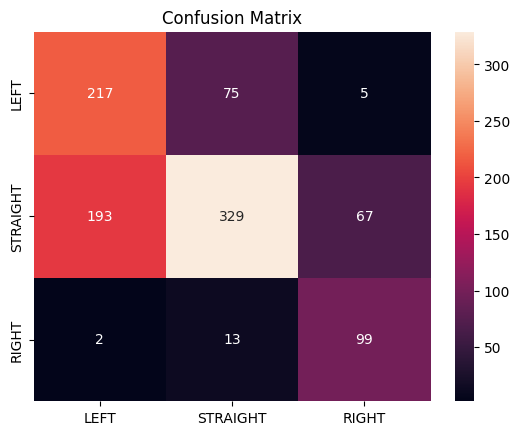

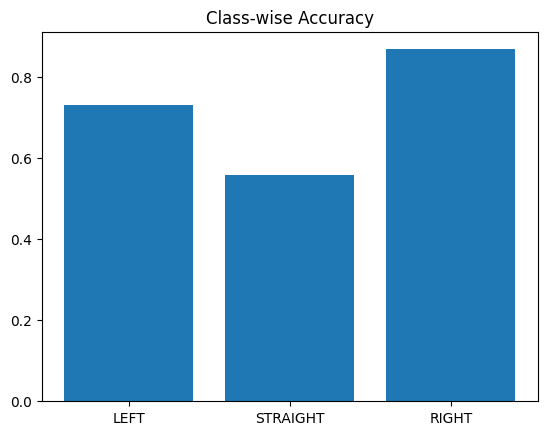

In [ ]:
import torch
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load model
model = DrivingNet()
model.load_state_dict(torch.load("driving_model.pt", map_location="cpu"))
model.eval()
# helps in evaluating the model
# Load data
with open("driving_data.pkl", "rb") as f:
    data = pickle.load(f)

# Convert steering → class
def to_class(angle):
    if angle < -0.1:
        return 0
    elif angle > 0.1:
        return 2
    else:
        return 1

labels = ["LEFT", "STRAIGHT", "RIGHT"]

y_true = []
y_pred = []

print("🚀 Evaluating...")

for img, steer in data[:1000]:
    img_tensor = torch.FloatTensor(img).unsqueeze(0)

    with torch.no_grad():
        pred = model(img_tensor).item()

    y_true.append(to_class(steer))
    y_pred.append(to_class(pred))

# Metrics
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", acc)
print(classification_report(y_true, y_pred, target_names=labels))

# Confusion Matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.show()

# Accuracy Graph
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(labels, class_acc)
plt.title("Class-wise Accuracy")
plt.show()

In [3]:
pip install scikit-learn seaborn matplotlib

     ---------------------------------------- 7.1/7.1 MB 3.1 MB/s eta 0:00:00
     -------------------------------------- 302.2/302.2 kB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
